In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from run_models import run_VAE
from utils.common import extract_latents_with_names, combine_audio_and_lyrics
from datasets import AudioSpectogramGenreDataset

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch, numpy as np, shutil, pandas as pd
from pathlib import Path

1. Create the new dataset
2. Conditional VAE = Convolutional VAE w supervised dataset???
3. Which functions are reusable??
4. Overall workflow???

In [4]:
from run_models import run_VAE, run_PCA, run_KMeans
from utils.common import extract_latents

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
root = Path("../..")

In [7]:
npy_dir = root / config.FEATURES_DIR
num_labels = 0
df_meta_path = root / config.METADATA_DIR / "metadata_en.csv" # "metadata_popular_en.csv" if considering only genres that appear > 10x

In [27]:
cvae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="cvae", root=root) #type: ignore

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-09 03:48:01,313] A new study created in memory with name: Conditional VAE Tuning
  0%|          | 0/3 [00:00<?, ?it/s]D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([32, 1, 64, 91])) that is different to the input size (torch.Size([32, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([16, 1, 64, 91])) that is different to the input size (torch.Size([16, 64, 91])). This will likely lead to incorrect results due to broadcasting.

--------------------------------------------------
Epoch 1 / 3
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 10230.6206   | 4508.8352   
Recon        | 10207.9790   | 4490.4836   
KL Div       | 75.4723      | 61.1720     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 3
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 4496.1570    | 4329.3335   
Recon        | 4479.1385    | 4312.3667   
KL Div       | 56.7284      | 56.5561     
--------------------------------------------------



  0%|          | 0/3 [00:30<?, ?it/s]

--------------------------------------------------
Epoch 3 / 3
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 4453.3570    | 4098.3694   
Recon        | 4439.0919    | 4084.1517   
KL Div       | 47.5504      | 47.3922     
--------------------------------------------------

[I 2026-04-09 03:48:32,127] Trial 0 finished with value: 2469.4479036621096 and parameters: {'HIDDEN_DIM_1': 1024, 'HIDDEN_DIM_2': 128, 'LATENT_DIM': 32, 'LR': 0.0005105903209394755, 'BATCH_SIZE': 32, 'BETA': 5.0}. Best is trial 0 with value: 2469.4479036621096.


Best trial: 0. Best value: 2469.45:  33%|███▎      | 1/3 [00:31<01:02, 31.08s/it]D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([64, 1, 64, 91])) that is different to the input size (torch.Size([64, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([52, 1, 64, 91])) that is different to the input size (torch.Size([52, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")


...

--------------------------------------------------
Epoch 3 / 3
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 8717.9092    | 9094.9803   
Recon        | 8705.6682    | 9082.4601   
KL Div       | 40.8031      | 41.7335     
--------------------------------------------------

[I 2026-04-09 03:48:43,962] Trial 2 finished with value: 5466.169475781249 and parameters: {'HIDDEN_DIM_1': 2048, 'HIDDEN_DIM_2': 512, 'LATENT_DIM': 32, 'LR': 0.0004597505784732166, 'BATCH_SIZE': 64, 'BETA': 2.0}. Best is trial 0 with value: 2469.4479036621096.


Best trial: 0. Best value: 2469.45: 100%|██████████| 3/3 [00:42<00:00, 14.30s/it]
[W 2026-04-09 03:48:44,312] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,313] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,314] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,314] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,315] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,315] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,316] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,316] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,317] Param LATENT_DIM unique value length is less than 2.
[W 2026-04-09 03:48:44,317] Param LATENT_DIM unique value length is less than 2.


Saved: results\trials\plots\cvae\optimization_history.html
Saved: results\trials\plots\cvae\param_importances.html
Saved: results\trials\plots\cvae\parallel_coordinate.html
Saved: results\trials\plots\cvae\edf.html
Saved: results\trials\plots\cvae\timeline.html
Saved: results\trials\plots\cvae\contour.html
Best trial for `cvae`:
Score: 2469.4479
    HIDDEN_DIM_1              1024
    HIDDEN_DIM_2              128
    LATENT_DIM                32
    LR                        0.0005105903209394755
    BATCH_SIZE                32
    BETA                      5.0


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=5843, out_features=1024, bias=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Linear(in_features=1024, out_features=128, bias=True)
      (4): LeakyReLU(negative_slope=0.01, inplace=True)
    )
    (mu_layer): Linear(in_features=128, out_features=32, bias=True)
    

D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([32, 1, 64, 91])) that is different to the input size (torch.Size([32, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([16, 1, 64, 91])) that is different to the input size (torch.Size([16, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:40: UserWarning: Using a target size (torch.Size([20, 1, 64, 91])) that is different to the input size (torch.Size([20, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please 

--------------------------------------------------
Epoch 1 / 3
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 9108.6934    | 4456.0121   
Recon        | 9089.1577    | 4434.9791   
KL Div       | 65.1190      | 70.1099     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 3
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 4620.1679    | 4527.9088   
Recon        | 4601.8360    | 4511.7382   
KL Div       | 61.1064      | 53.9021     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 3
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 4269.5544    | 4333.8743   
Recon        | 4253.1379    | 4318.8981   
KL Div       | 54.7218      | 49.9206     
--------------------------------------

In [28]:
pca_baseline, pca_history = run_PCA(n_components=latent_dim, train_loader=train_loader, test_loader=test_loader)

In [37]:
train_latents, train_labels = extract_latents(model=cvae, loader=train_loader, device=device)
test_latents,  test_labels  = extract_latents(model=cvae, loader=test_loader,  device=device)

In [38]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)
vae_labels  = np.concatenate([train_labels,  test_labels],  axis=0)

In [39]:
pca_latents = np.concatenate([
        pca_baseline.transform(train_loader),
        pca_baseline.transform(test_loader)
    ])

In [43]:
vae_kmeans, vae_metrics = run_KMeans(vae_latents, model_type="cvae")

True



Optimal k        : 5
Inertia (WCSS)   : 172.9393
Silhouette Score : 0.3375
CH Index         : 2146.0312





<Figure size 800x550 with 0 Axes>

In [41]:
pca_kmeans, pca_metrics = run_KMeans(pca_latents, model_type="pca")




Optimal k        : 5
Inertia (WCSS)   : 109711.3281
Silhouette Score : 0.2279
CH Index         : 696.8179





<Figure size 800x550 with 0 Axes>

In [44]:
from collections import Counter

for cluster_id in range(5):
    mask = vae_kmeans.labels_ == cluster_id
    genre_counts = Counter(vae_labels[mask])
    print(f"Cluster {cluster_id}: {genre_counts}")

Cluster 0: Counter({np.int64(0): 467, np.int64(1): 58, np.int64(3): 49, np.int64(4): 47, np.int64(2): 37, np.int64(5): 20, np.int64(6): 10, np.int64(8): 9, np.int64(7): 6, np.int64(9): 3, np.int64(17): 3, np.int64(14): 2, np.int64(12): 2, np.int64(16): 2, np.int64(10): 1, np.int64(15): 1, np.int64(13): 1})
Cluster 1: Counter({np.int64(0): 541, np.int64(1): 53, np.int64(3): 46, np.int64(2): 22, np.int64(7): 18, np.int64(5): 14, np.int64(4): 10, np.int64(6): 9, np.int64(9): 6, np.int64(11): 6, np.int64(12): 4, np.int64(8): 4, np.int64(16): 2, np.int64(10): 2, np.int64(14): 2, np.int64(15): 2, np.int64(13): 1, np.int64(18): 1})
Cluster 2: Counter({np.int64(0): 56, np.int64(4): 37, np.int64(3): 18, np.int64(2): 12, np.int64(5): 10, np.int64(8): 9, np.int64(1): 4, np.int64(7): 2, np.int64(10): 1, np.int64(12): 1, np.int64(6): 1})
Cluster 3: Counter({np.int64(0): 192, np.int64(4): 87, np.int64(3): 55, np.int64(2): 54, np.int64(5): 27, np.int64(1): 27, np.int64(7): 22, np.int64(8): 22, np.int

In [47]:
from visualizations import plot_tsne_pca_vs_vae

In [46]:
from sklearn.metrics import silhouette_score

Computing t-SNE for PCA features...
Computing t-SNE for VAE features...
Saved → ..\..\results\clustering\tsne_pca_vs_vae.png


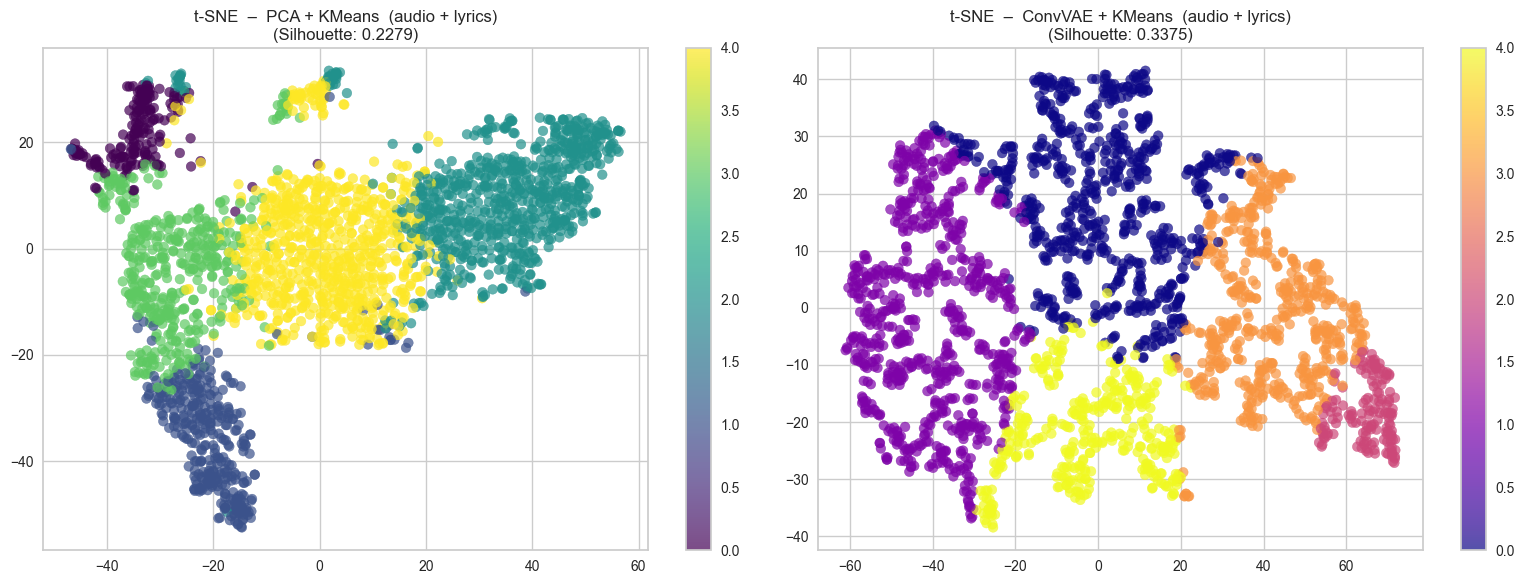

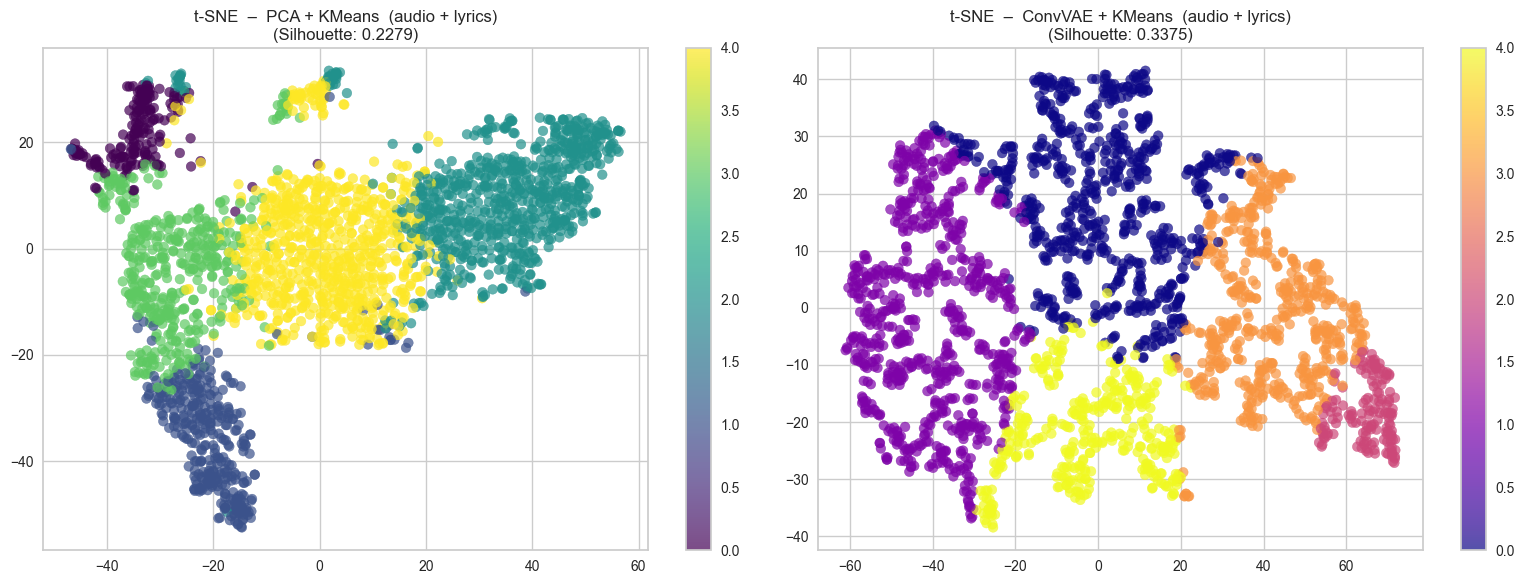

In [49]:
plot_tsne_pca_vs_vae(
    pca_latents  = pca_latents,
    vae_latents  = vae_latents,
    pca_clusters = pca_kmeans.labels_,
    vae_clusters = vae_kmeans.labels_,
    pca_sil      = pca_metrics["silhouette"],
    vae_sil      = vae_metrics["silhouette"],
    save_path    = root / config.RESULT_DIR / "clustering" / "tsne_pca_vs_vae.png"
)